# Kernel Composition

A single kernel can only model one kind of structure. Real signals usually have
several: a trend plus a seasonal cycle, growth times oscillation, and so on.
LightGP exposes kernel composition via familiar Python operators:

- `k1 + k2` — `SumKernel` (additive structure)
- `k1 * k2` — `ProductKernel` (multiplicative structure)
- `gp.Scale(k)` — wraps a kernel with a learnable output scale

We will demonstrate the additive pattern on a Mauna Loa-CO₂-shaped signal.

In [1]:
import os
import sys

# Make the locally-built lightgp importable. Real users install via 'pip install lightgp'.
sys.path.insert(0, os.path.abspath(os.path.join("..", "..", "..", "python")))

import numpy as np
import matplotlib.pyplot as plt
import lightgp as gp

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (8, 3.5), "figure.dpi": 90})

## Generate synthetic data

Linear trend + slight curvature + annual seasonality + small noise.

In [2]:
N = 300
t = np.linspace(0, 30, N, dtype=np.float32).reshape(-1, 1)  # 30 years, monthly samples
y = (1.5 * t[:, 0]
     + 0.04 * t[:, 0]**2
     + 3.0 * np.sin(2 * np.pi * t[:, 0])
     + 0.5 * rng.standard_normal(N)).astype(np.float32)
t_test = np.linspace(0, 35, 400).reshape(-1, 1).astype(np.float32)  # extrapolate beyond training

## Baseline: a single RBF

A wide RBF + LinearMean can capture the trend but not the seasonality.

In [3]:
m_rbf = gp.GPExact(
    gp.RBF(length_scale=2.0, signal_var=10.0),
    mean=gp.LinearMean(input_dim=1),
    noise_var=0.5,
)
m_rbf.fit(t, y)
m_rbf.optimize(steps=80)
p_rbf = m_rbf.predict(t_test)

## Composed kernel

`Scale(RBF_long) + Scale(Periodic) + Scale(RBF_short)`:

In [4]:
kernel = (gp.Scale(gp.RBF(length_scale=10.0))           # decade-scale trend wiggle
          + gp.Scale(gp.Periodic(length_scale=1.0, period=1.0))   # annual cycle
          + gp.Scale(gp.RBF(length_scale=0.5)))         # short-term irregular
print("kernel:", kernel.name())
print("num parameters:", kernel.num_params())

m_comp = gp.GPExact(kernel, mean=gp.LinearMean(input_dim=1), noise_var=0.5)
m_comp.fit(t, y)
m_comp.optimize(steps=120)
p_comp = m_comp.predict(t_test)

kernel: ((Scale(RBF) + Scale(Periodic)) + Scale(RBF))
num parameters: 10


## Compare side-by-side

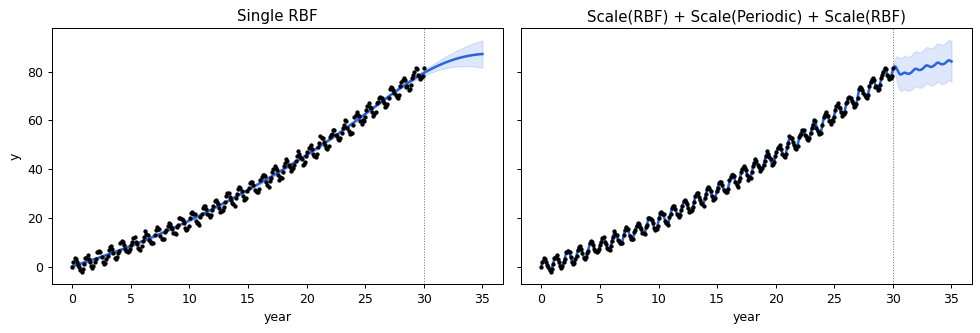

In [5]:
def panel(ax, p, title):
    mu, sd = p["mean"], np.sqrt(np.maximum(p["var"], 0))
    ax.fill_between(t_test[:, 0], mu - 2*sd, mu + 2*sd, alpha=0.15, color="#2563EB")
    ax.plot(t_test[:, 0], mu, lw=2, color="#2563EB")
    ax.scatter(t[:, 0], y, s=6, color="black", zorder=3)
    ax.axvline(30, color="#6B7280", ls=":", lw=0.8)
    ax.set_title(title); ax.set_xlabel("year")

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
panel(a, p_rbf, "Single RBF")
panel(b, p_comp, "Scale(RBF) + Scale(Periodic) + Scale(RBF)")
a.set_ylabel("y")
plt.tight_layout(); plt.show()

## What to compose, when?

| Pattern | Combiner | Example |
|---------|----------|---------|
| Two independent structures present at the same scale | `+` | Trend + seasonality |
| One signal modulates the amplitude of another | `*` | Growing seasonal wave |
| Two patterns each need their own output scale | `Scale(k1) + Scale(k2)` | Almost always — gives the optimizer per-component freedom |

A common starting recipe:

```python
kernel = gp.Scale(gp.RBF()) + gp.Scale(gp.Periodic(period=p_initial))
```

The next tutorial scales these ideas up with sparse inducing-point GPs.